# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Telecom Fraud Detection Dataset](https://www.kaggle.com/datasets/velvetcrystal/telecom-fraud-detection-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('telecom_fraud_detection_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,call_id,caller_age_days,calls_per_day,call_duration_sec,avg_call_duration_sec,unique_receivers_24h,receiver_block_rate,spam_reports_count,country_code_risk_score,night_call_ratio,sequential_dialing_score,graph_degree,previous_fraud_associations,reputation_score,fraud_label
0,CALL0000001,735,7,449,372.5,9,12.60,4,26.08,15.18,5.19,59,0,88.06,0
1,CALL0000002,63,4,29,26.3,8,52.01,2,41.33,33.81,87.34,57,23,23.50,1
2,CALL0000003,473,24,61,72.8,6,5.24,1,3.12,25.49,32.84,48,0,74.23,0
3,CALL0000004,91,1270,27,37.1,156,36.88,72,50.15,59.64,98.80,351,15,41.23,1
4,CALL0000005,14,1344,69,64.8,135,72.19,3,42.58,85.61,51.92,575,28,17.94,1


## last Five row

In [4]:
df.tail()

,call_id,caller_age_days,calls_per_day,call_duration_sec,avg_call_duration_sec,unique_receivers_24h,receiver_block_rate,spam_reports_count,country_code_risk_score,night_call_ratio,sequential_dialing_score,graph_degree,previous_fraud_associations,reputation_score,fraud_label
9995,CALL0009996,1226,852,35,28.0,81,53.91,79,45.66,70.67,97.53,521,18,35.71,1
9996,CALL0009997,2946,13,531,383.9,10,9.24,3,39.16,11.62,17.66,20,1,75.91,0
9997,CALL0009998,24,1438,6,7.2,150,55.84,2,44.36,38.25,62.61,313,25,8.12,1
9998,CALL0009999,33,1024,25,1.0,95,43.23,102,64.42,34.91,39.76,212,18,4.15,1
9999,CALL0010000,918,17,334,390.9,7,5.02,2,37.38,4.66,34.33,131,0,84.10,0


## Shape of our dataset

In [5]:
df.shape

(10000, 15)

## List out all columns

In [6]:
df.columns

Index(['call_id', 'caller_age_days', 'calls_per_day', 'call_duration_sec',
       'avg_call_duration_sec', 'unique_receivers_24h', 'receiver_block_rate',
       'spam_reports_count', 'country_code_risk_score', 'night_call_ratio',
       'sequential_dialing_score', 'graph_degree',
       'previous_fraud_associations', 'reputation_score', 'fraud_label'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

call_id                         object
caller_age_days                  int64
calls_per_day                    int64
call_duration_sec                int64
avg_call_duration_sec          float64
unique_receivers_24h             int64
receiver_block_rate            float64
spam_reports_count               int64
country_code_risk_score        float64
night_call_ratio               float64
sequential_dialing_score       float64
graph_degree                     int64
previous_fraud_associations      int64
reputation_score               float64
fraud_label                      int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   call_id                      10000 non-null  object 
 1   caller_age_days              10000 non-null  int64  
 2   calls_per_day                10000 non-null  int64  
 3   call_duration_sec            10000 non-null  int64  
 4   avg_call_duration_sec        10000 non-null  float64
 5   unique_receivers_24h         10000 non-null  int64  
 6   receiver_block_rate          10000 non-null  float64
 7   spam_reports_count           10000 non-null  int64  
 8   country_code_risk_score      10000 non-null  float64
 9   night_call_ratio             10000 non-null  float64
 10  sequential_dialing_score     10000 non-null  float64
 11  graph_degree                 10000 non-null  int64  
 12  previous_fraud_associations  10000 non-null  int64  
 13  reputation_score 

## Check Null Value

In [9]:
df.isnull().sum()

call_id                        0
caller_age_days                0
calls_per_day                  0
call_duration_sec              0
avg_call_duration_sec          0
unique_receivers_24h           0
receiver_block_rate            0
spam_reports_count             0
country_code_risk_score        0
night_call_ratio               0
sequential_dialing_score       0
graph_degree                   0
previous_fraud_associations    0
reputation_score               0
fraud_label                    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,caller_age_days,calls_per_day,call_duration_sec,avg_call_duration_sec,unique_receivers_24h,receiver_block_rate,spam_reports_count,country_code_risk_score,night_call_ratio,sequential_dialing_score,graph_degree,previous_fraud_associations,reputation_score,fraud_label
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,773.626600,237.47800,213.367100,210.615840,50.356400,25.088838,18.030500,38.600140,31.241817,33.093151,163.497400,5.043000,63.496163,0.30000
std,728.549185,406.43526,163.899768,177.032595,77.776385,26.525415,32.166751,22.141158,22.258562,27.996123,149.269361,9.117415,26.654174,0.45828
min,0.000000,1.00000,1.000000,1.000000,0.000000,0.090000,0.000000,0.400000,0.180000,0.180000,1.000000,0.000000,0.360000,0.00000
25%,244.000000,6.00000,62.000000,55.800000,7.000000,5.960000,1.000000,20.590000,13.620000,11.310000,61.000000,0.000000,43.080000,0.00000
50%,618.000000,13.00000,198.000000,182.100000,9.000000,11.460000,2.000000,35.620000,24.810000,21.110000,108.000000,0.000000,72.730000,0.00000
75%,1088.000000,317.25000,314.000000,311.125000,73.000000,46.117500,4.000000,54.740000,45.662500,56.102500,220.000000,2.000000,84.882500,1.00000
max,3650.000000,1500.00000,1170.000000,1404.900000,524.000000,98.340000,111.000000,99.220000,98.220000,99.660000,1000.000000,41.000000,99.770000,1.00000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

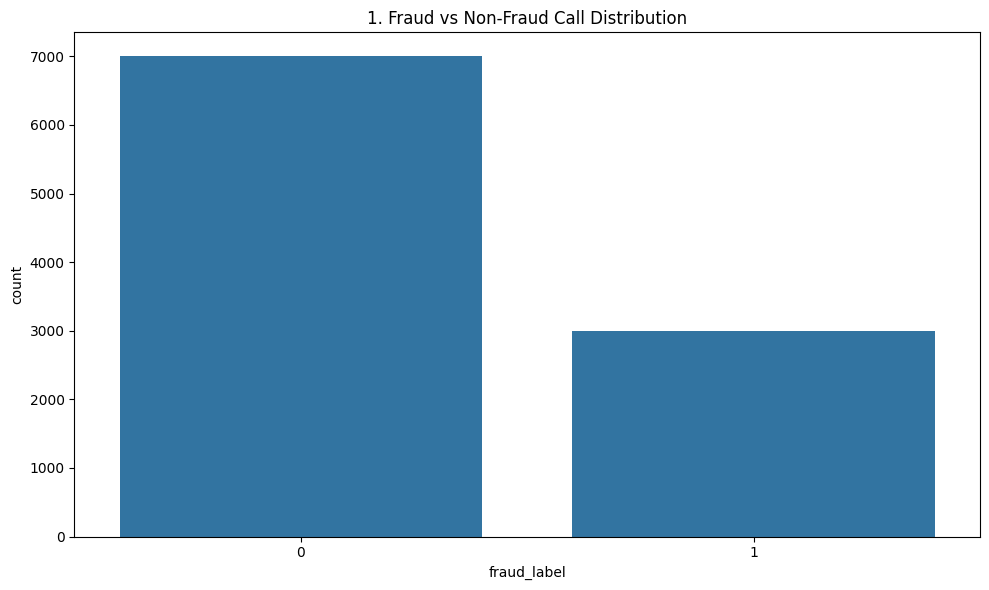

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='fraud_label')
plt.title(f'{plot_no}. Fraud vs Non-Fraud Call Distribution')
show_fig()
plot_no += 1

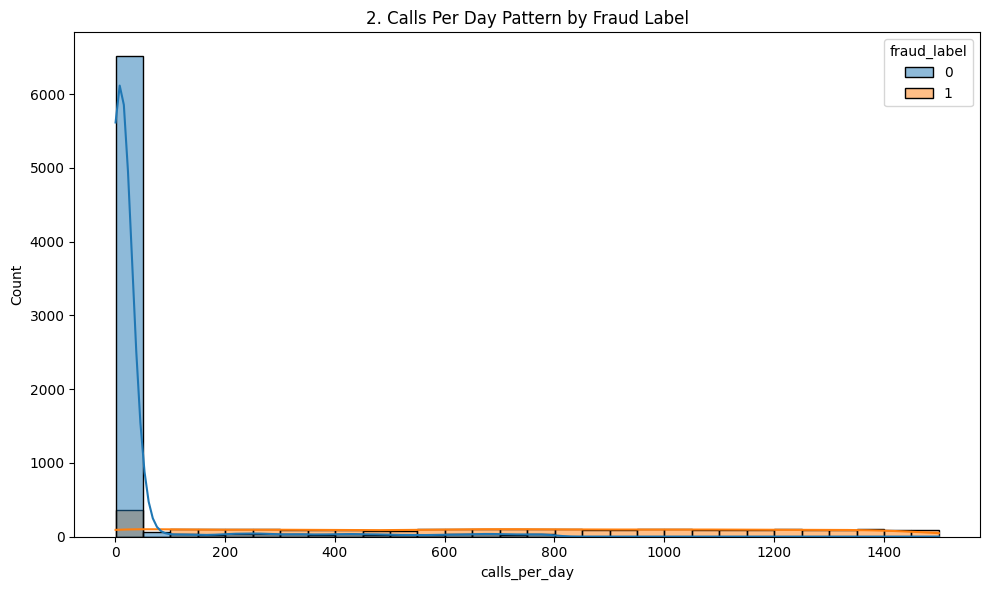

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='calls_per_day', hue='fraud_label', bins=30, kde=True)
plt.title(f'{plot_no}. Calls Per Day Pattern by Fraud Label')
show_fig()
plot_no += 1

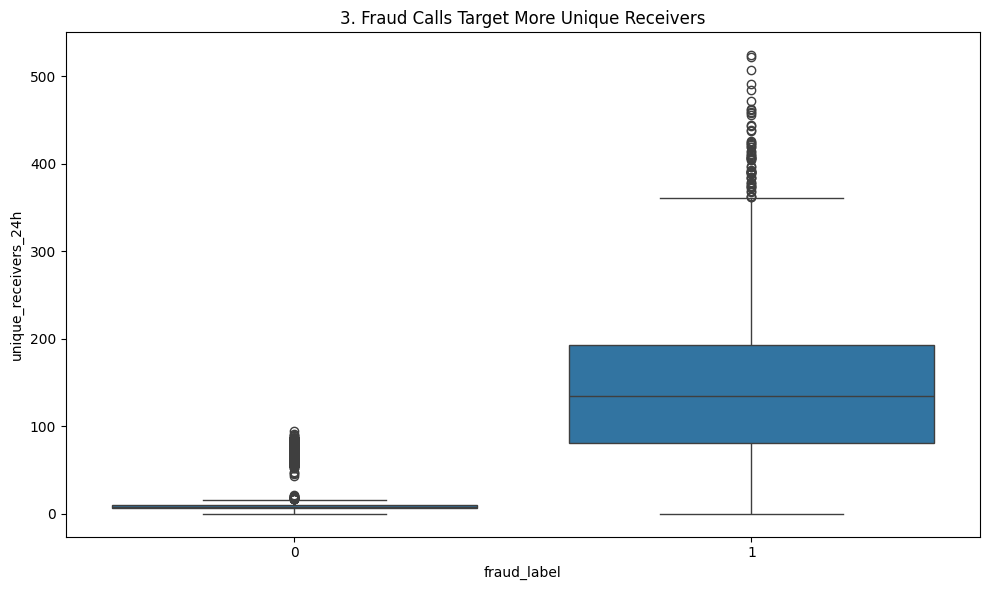

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fraud_label', y='unique_receivers_24h')
plt.title(f'{plot_no}. Fraud Calls Target More Unique Receivers')
show_fig()
plot_no += 1

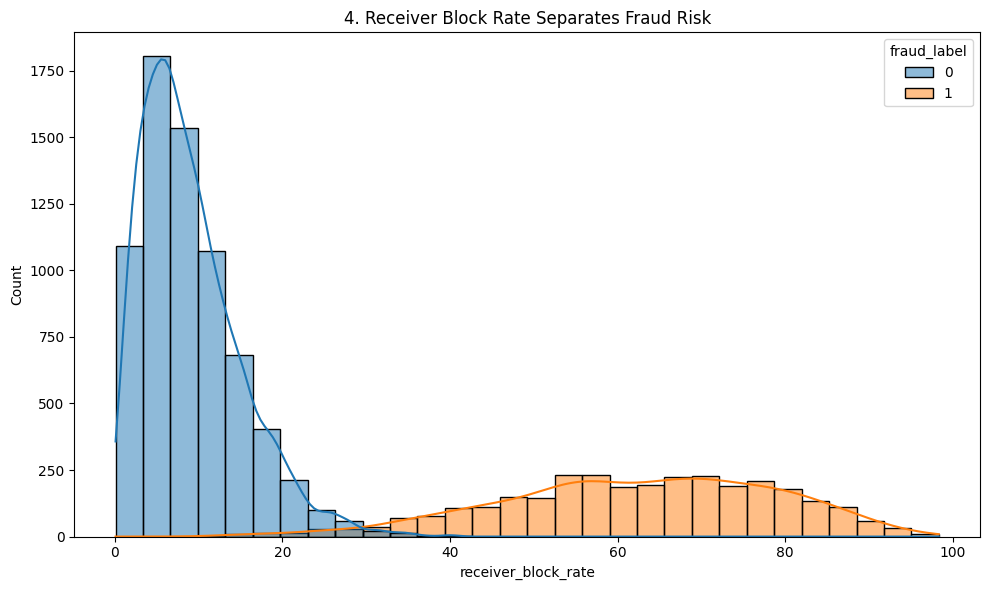

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='receiver_block_rate', hue='fraud_label', bins=30, kde=True)
plt.title(f'{plot_no}. Receiver Block Rate Separates Fraud Risk')
show_fig()
plot_no += 1

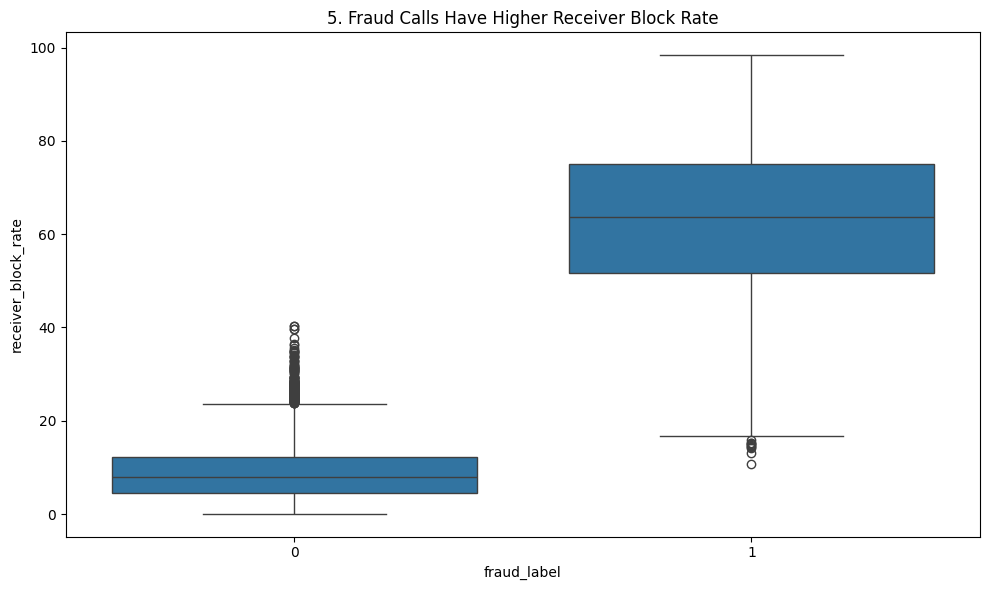

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fraud_label', y='receiver_block_rate')
plt.title(f'{plot_no}. Fraud Calls Have Higher Receiver Block Rate')
show_fig()
plot_no += 1

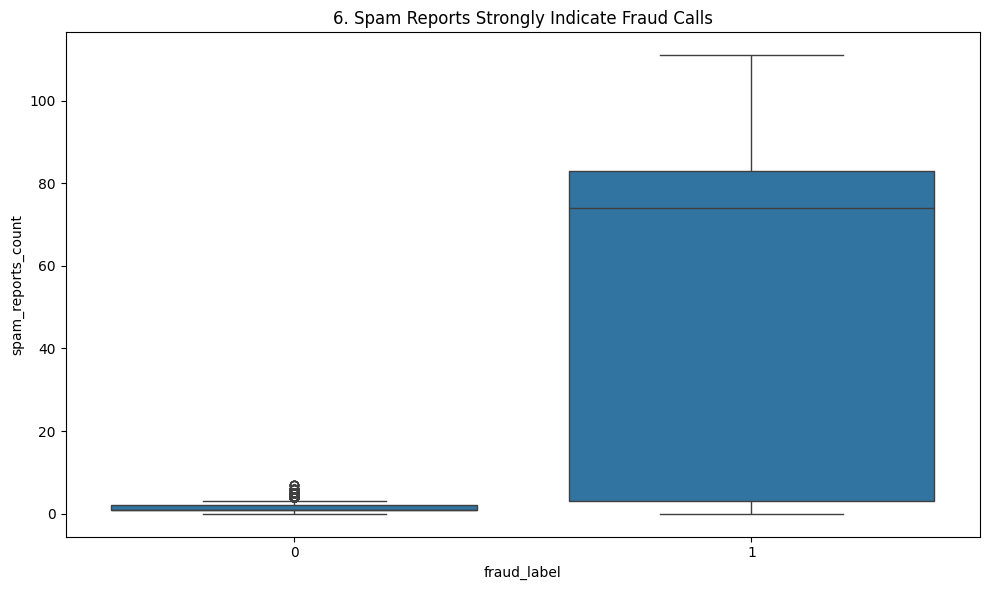

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fraud_label', y='spam_reports_count')
plt.title(f'{plot_no}. Spam Reports Strongly Indicate Fraud Calls')
show_fig()
plot_no += 1

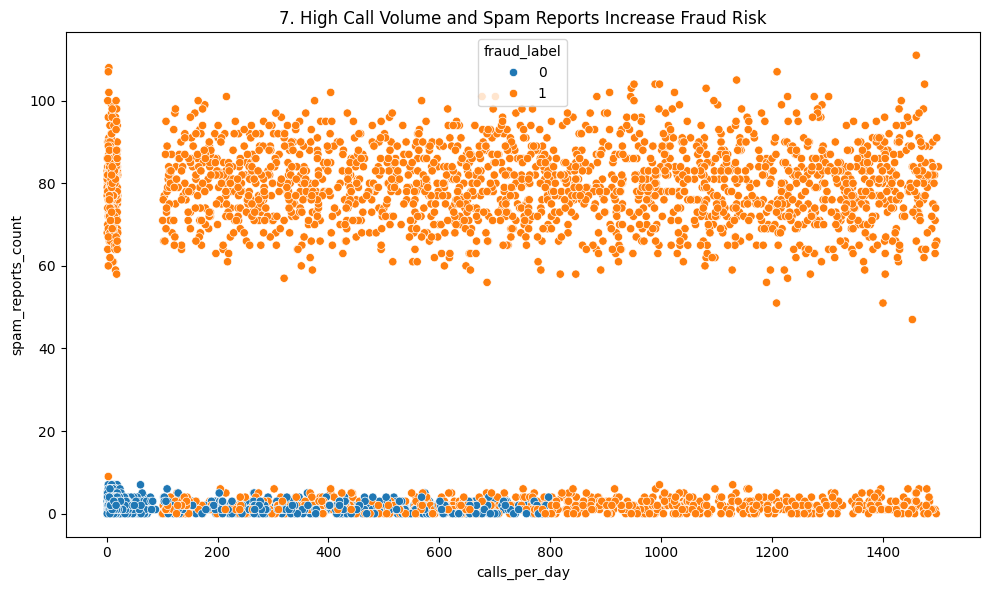

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='calls_per_day', y='spam_reports_count', hue='fraud_label')
plt.title(f'{plot_no}. High Call Volume and Spam Reports Increase Fraud Risk')
show_fig()
plot_no += 1

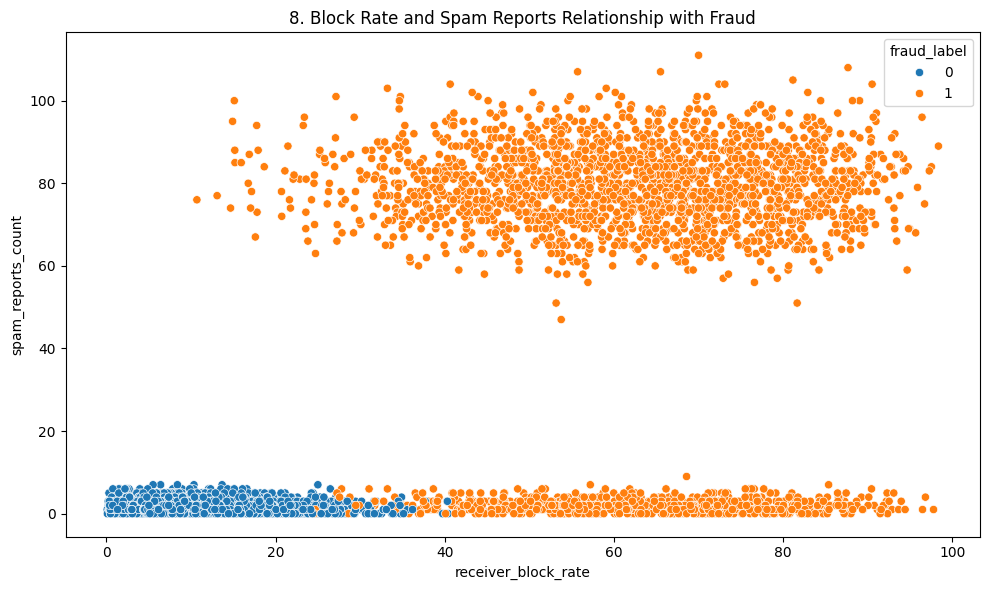

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='receiver_block_rate', y='spam_reports_count', hue='fraud_label')
plt.title(f'{plot_no}. Block Rate and Spam Reports Relationship with Fraud')
show_fig()
plot_no += 1

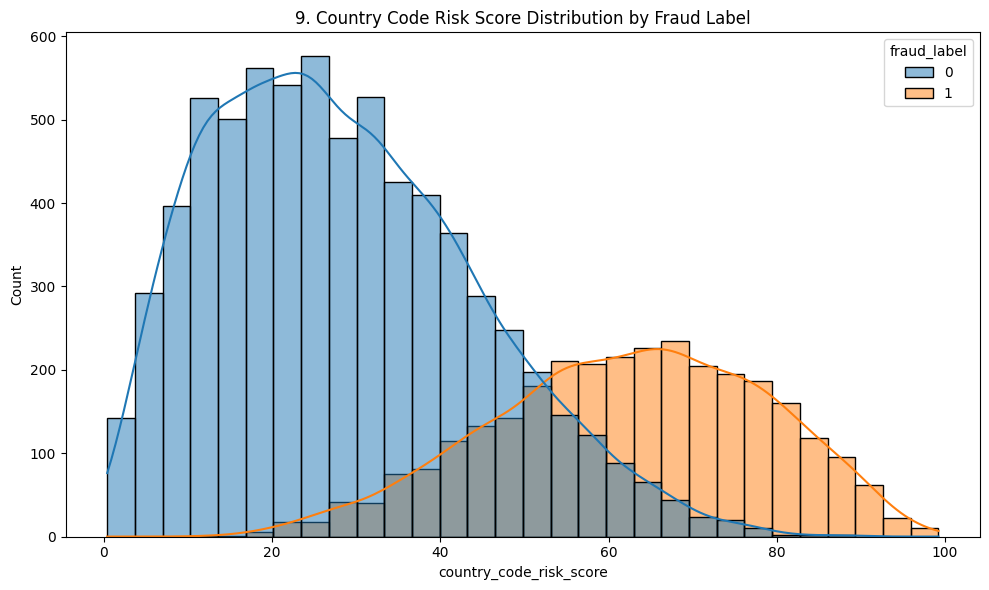

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='country_code_risk_score', hue='fraud_label', bins=30, kde=True)
plt.title(f'{plot_no}. Country Code Risk Score Distribution by Fraud Label')
show_fig()
plot_no += 1

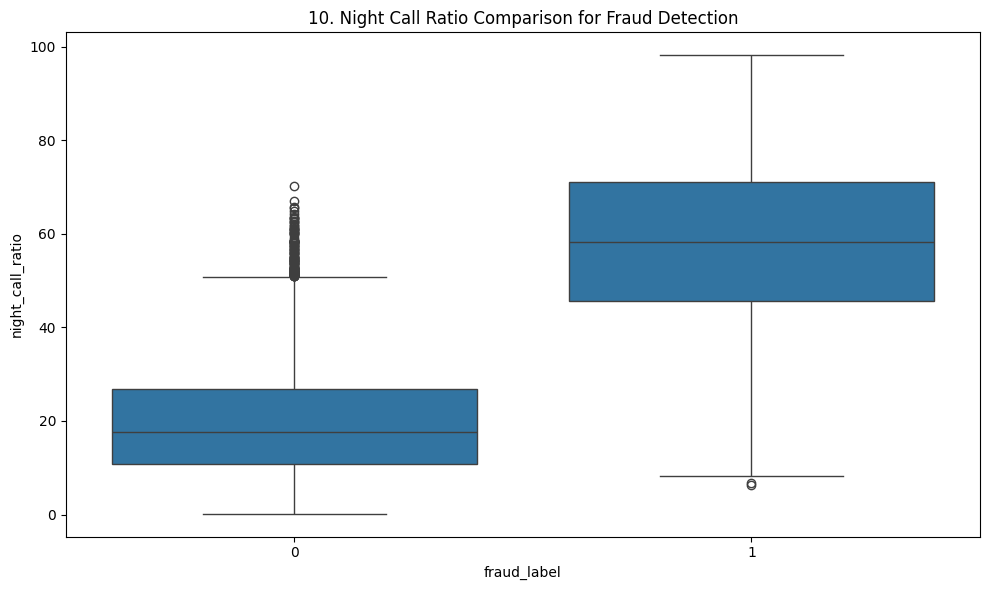

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fraud_label', y='night_call_ratio')
plt.title(f'{plot_no}. Night Call Ratio Comparison for Fraud Detection')
show_fig()
plot_no += 1

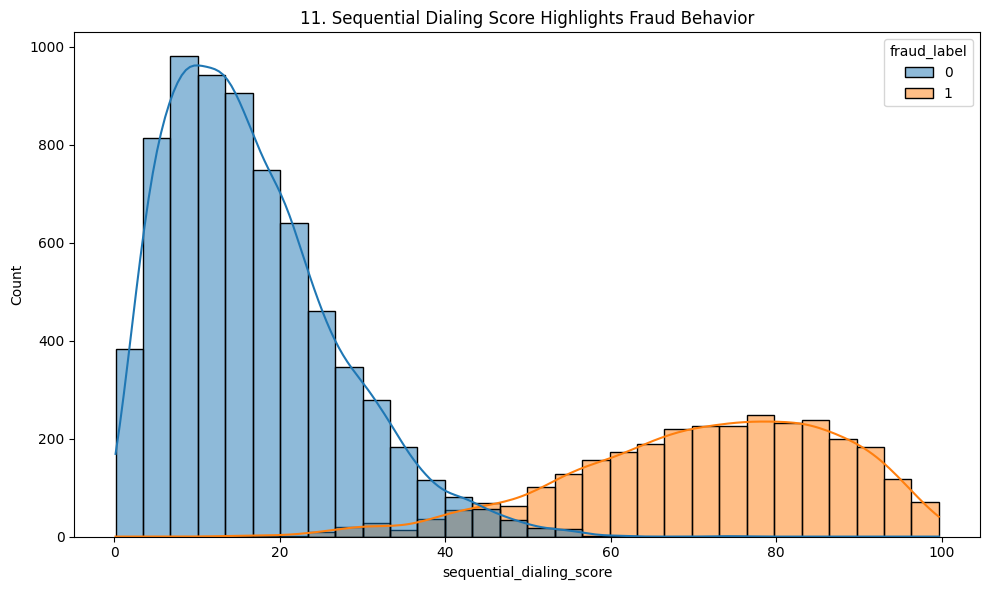

In [23]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='sequential_dialing_score', hue='fraud_label', bins=30, kde=True)
plt.title(f'{plot_no}. Sequential Dialing Score Highlights Fraud Behavior')
show_fig()
plot_no += 1

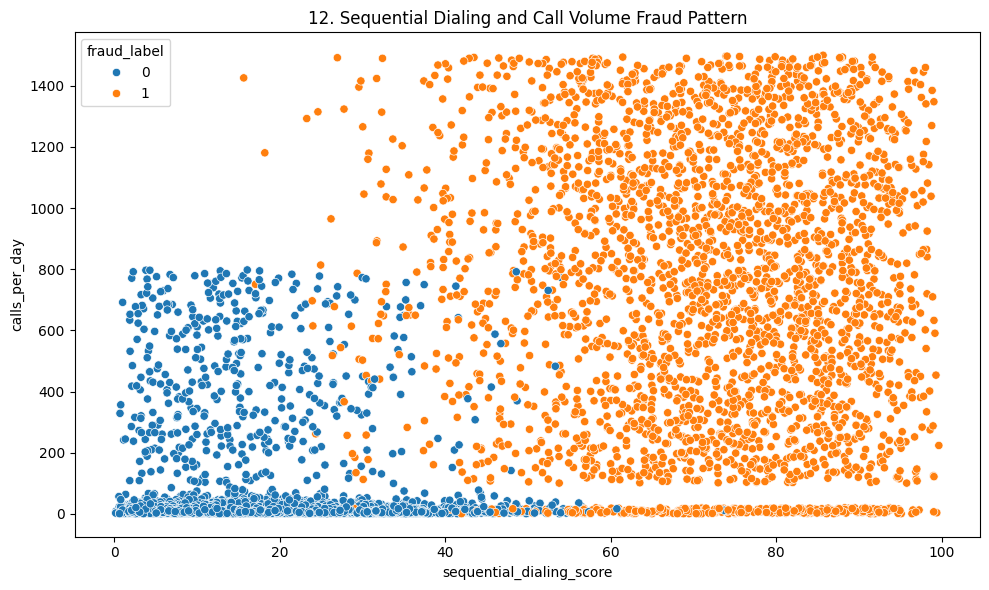

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sequential_dialing_score', y='calls_per_day', hue='fraud_label')
plt.title(f'{plot_no}. Sequential Dialing and Call Volume Fraud Pattern')
show_fig()
plot_no += 1

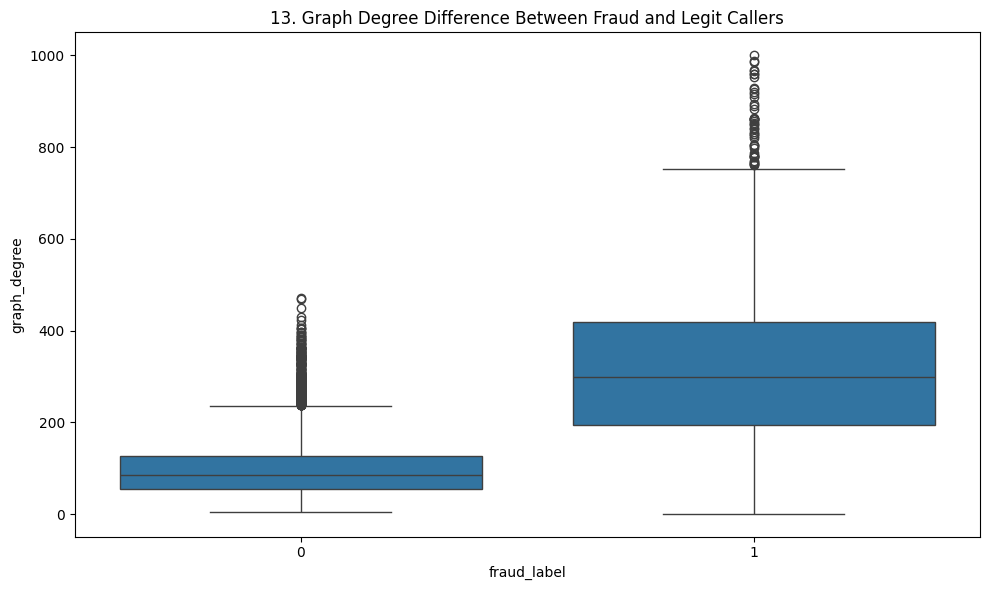

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fraud_label', y='graph_degree')
plt.title(f'{plot_no}. Graph Degree Difference Between Fraud and Legit Callers')
show_fig()
plot_no += 1

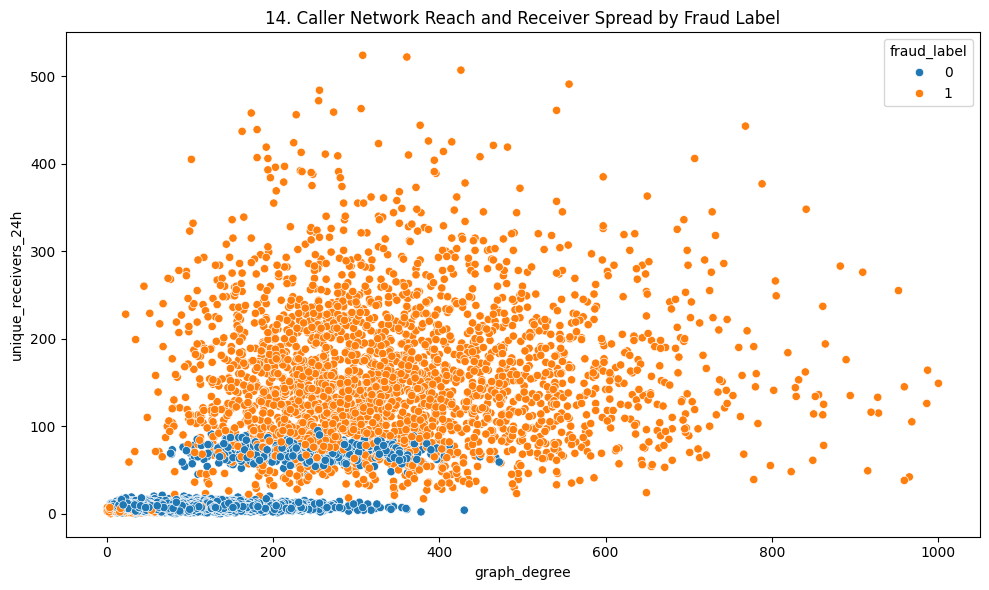

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='graph_degree', y='unique_receivers_24h', hue='fraud_label')
plt.title(f'{plot_no}. Caller Network Reach and Receiver Spread by Fraud Label')
show_fig()
plot_no += 1

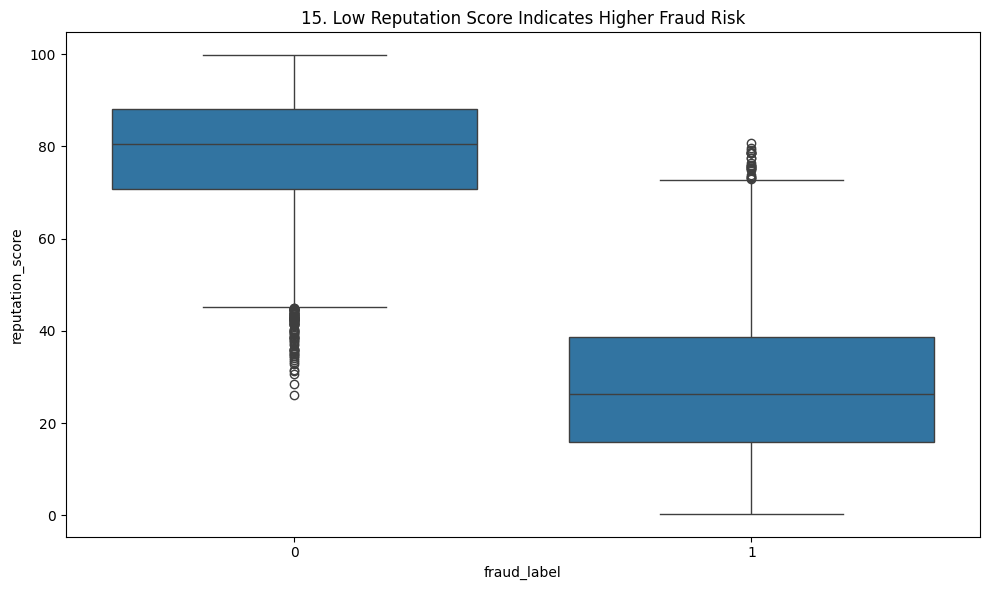

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fraud_label', y='reputation_score')
plt.title(f'{plot_no}. Low Reputation Score Indicates Higher Fraud Risk')
show_fig()
plot_no += 1

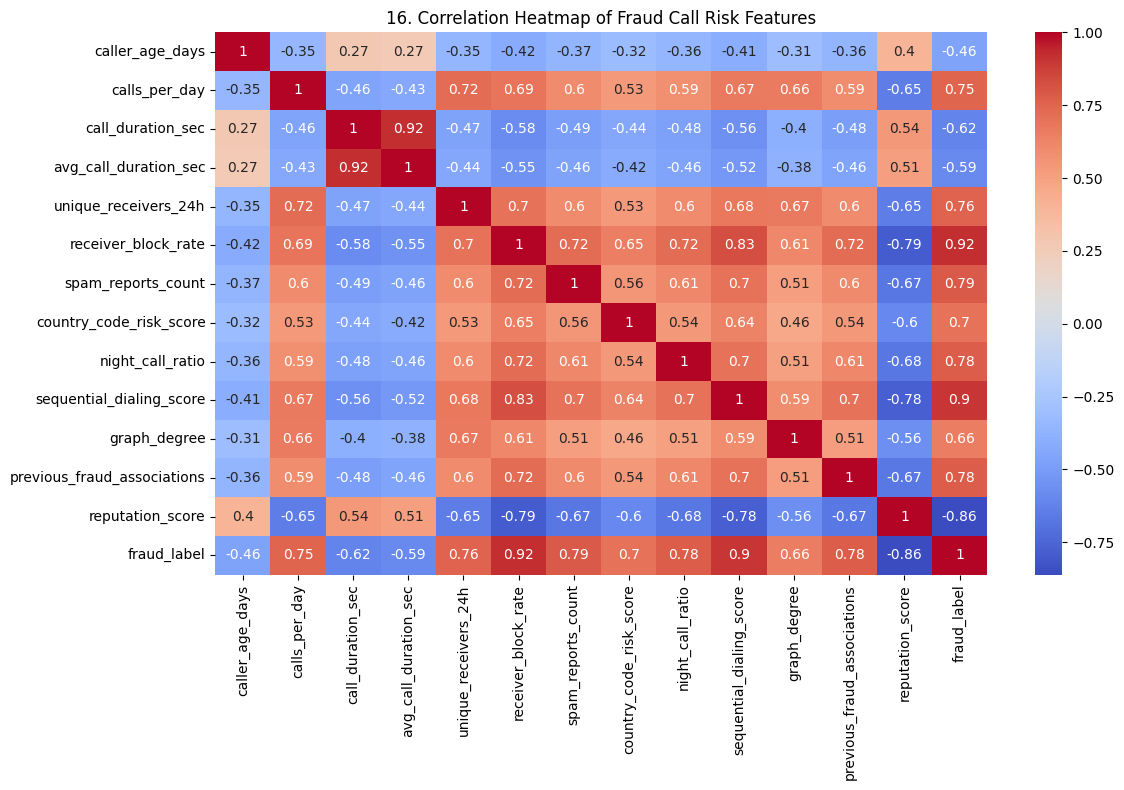

In [28]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Fraud Call Risk Features')
show_fig()
plot_no += 1

# Model Training

## Select only weak features

In [29]:
X = df[['caller_age_days','call_duration_sec','avg_call_duration_sec']]
y = df['fraud_label']

## Split data

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Create weak decision tree

In [31]:
model = DecisionTreeClassifier(
    max_depth=1,
    min_samples_split=100,
    random_state=42
)

## Train model

In [32]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Make predictions

In [33]:
y_pred = model.predict(X_test)

## Print accuracy

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9256666666666666


## Print classification report

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2115
           1       0.91      0.83      0.87       885

    accuracy                           0.93      3000
   macro avg       0.92      0.90      0.91      3000
weighted avg       0.93      0.93      0.92      3000



## Create confusion matrix

In [36]:
cm = confusion_matrix(y_test, y_pred)

## Plot confusion matrix

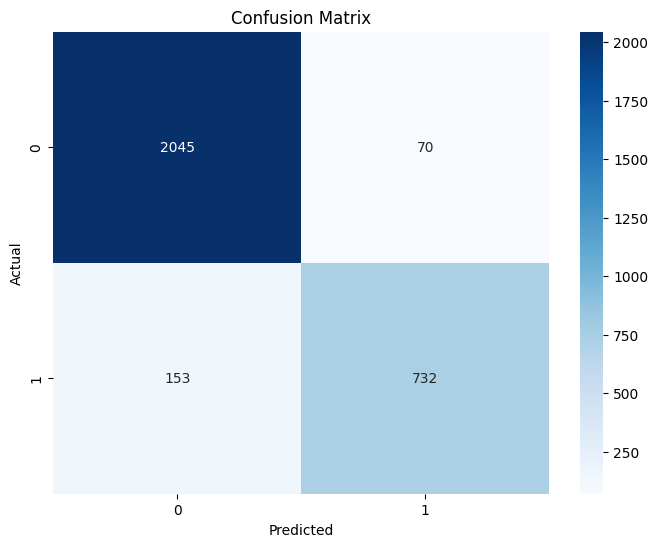

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()